In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_pkl(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

# Mapeamento label -> arquivo.
# Nota: "16 MB/s" e "1 partition (16MB/s)" apontam pro MESMO arquivo —
# esse trial serve nas duas comparações.
processing_files = {
    "1 partition (16MB/s)":  "processing_metrics_partition_1part_rate16.pkl",
    "3 partitions (16MB/s)": "processing_metrics_partition_3part_rate16.pkl",
    "4 MB/s":  "processing_metrics_rate_4mbps.pkl",
    "16 MB/s": "processing_metrics_partition_1part_rate16.pkl",
    "30 MB/s": "processing_metrics_rate_30mbps.pkl",
    "60 MB/s": "processing_metrics_rate_60mbps.pkl",
}

producer_files = {
    "1 partition (16MB/s)":  "producer_metrics_partition_1part_rate16.pkl",
    "3 partitions (16MB/s)": "producer_metrics_partition_3part_rate16.pkl",
    "4 MB/s":  "producer_metrics_rate_4mbps.pkl",
    "16 MB/s": "producer_metrics_partition_1part_rate16.pkl",
    "30 MB/s": "producer_metrics_rate_30mbps.pkl",
    "60 MB/s": "producer_metrics_rate_60mbps.pkl",
}

processing_data = {label: load_pkl(fname) for label, fname in processing_files.items()}
producer_data = {label: load_pkl(fname) for label, fname in producer_files.items()}

print("Trials carregados:", list(processing_data.keys()))

Trials carregados: ['1 partition (16MB/s)', '3 partitions (16MB/s)', '4 MB/s', '16 MB/s', '30 MB/s', '60 MB/s']


In [2]:
def snapshots_to_df(metrics):
    df = pd.DataFrame(metrics["snapshots"])
    if df.empty:
        return df
    df["elapsed_min"] = df["elapsed_s"] / 60
    # versões diferentes do código usaram "pending_futures" ou "queue_depth" —
    # normaliza pra um nome único
    if "pending_futures" not in df.columns and "queue_depth" in df.columns:
        df["pending_futures"] = df["queue_depth"]
    return df

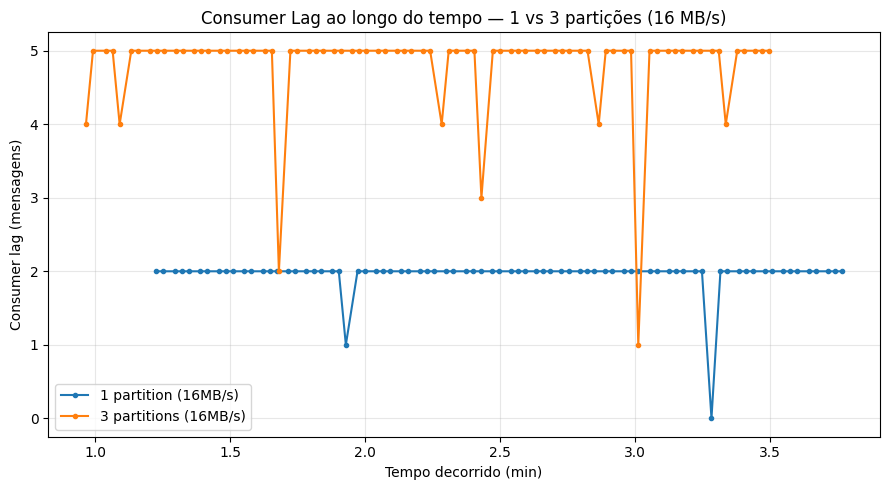

In [3]:
partition_labels = ["1 partition (16MB/s)", "3 partitions (16MB/s)"]

fig, ax = plt.subplots(figsize=(9, 5))
for label in partition_labels:
    df = snapshots_to_df(processing_data[label])
    ax.plot(df["elapsed_min"], df["consumer_lag"], marker='o', markersize=3, label=label)

ax.set_xlabel("Tempo decorrido (min)")
ax.set_ylabel("Consumer lag (mensagens)")
ax.set_title("Consumer Lag ao longo do tempo — 1 vs 3 partições (16 MB/s)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lag_partitioning_comparison.png", dpi=150)
plt.show()

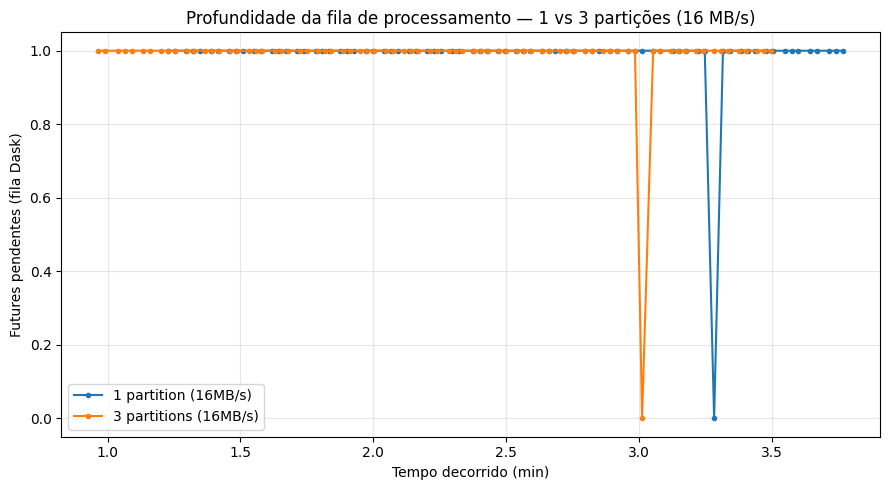

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for label in partition_labels:
    df = snapshots_to_df(processing_data[label])
    ax.plot(df["elapsed_min"], df["pending_futures"], marker='o', markersize=3, label=label)

ax.set_xlabel("Tempo decorrido (min)")
ax.set_ylabel("Futures pendentes (fila Dask)")
ax.set_title("Profundidade da fila de processamento — 1 vs 3 partições (16 MB/s)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("queue_partitioning_comparison.png", dpi=150)
plt.show()

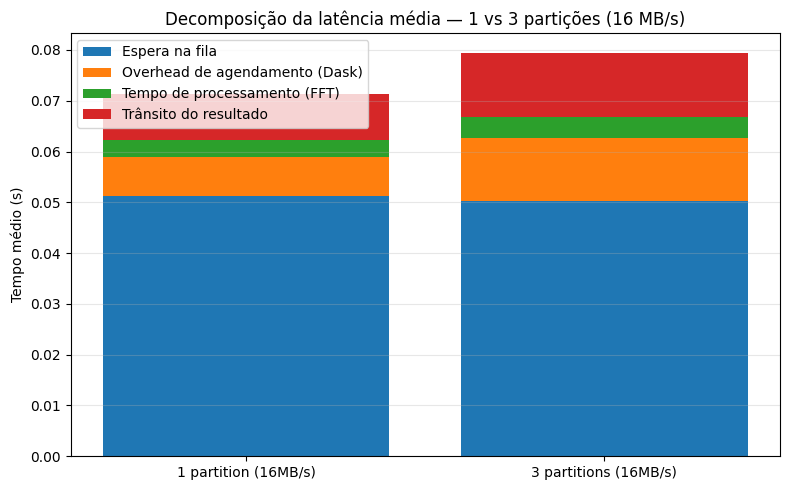

In [5]:
latency_components = ["queue_wait", "dask_scheduling_overhead", "service_time", "result_transit"]
component_labels_pt = {
    "queue_wait": "Espera na fila",
    "dask_scheduling_overhead": "Overhead de agendamento (Dask)",
    "service_time": "Tempo de processamento (FFT)",
    "result_transit": "Trânsito do resultado",
}

fig, ax = plt.subplots(figsize=(8, 5))
bottoms = np.zeros(len(partition_labels))
x_pos = np.arange(len(partition_labels))

for comp in latency_components:
    values = [processing_data[label][comp]["mean_s"] for label in partition_labels]
    ax.bar(x_pos, values, bottom=bottoms, label=component_labels_pt[comp])
    bottoms += np.array(values)

ax.set_xticks(x_pos)
ax.set_xticklabels(partition_labels)
ax.set_ylabel("Tempo médio (s)")
ax.set_title("Decomposição da latência média — 1 vs 3 partições (16 MB/s)")
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("latency_breakdown_partitioning.png", dpi=150)
plt.show()

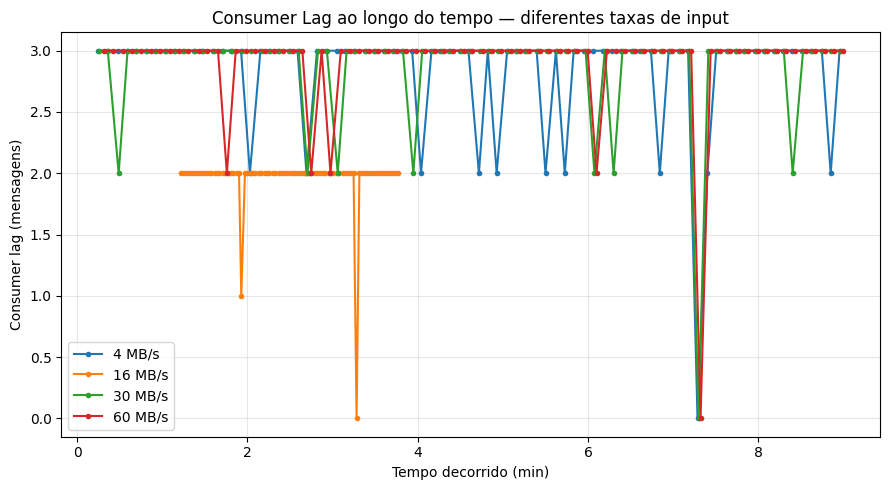

In [6]:
rate_labels = ["4 MB/s", "16 MB/s", "30 MB/s", "60 MB/s"]

fig, ax = plt.subplots(figsize=(9, 5))
for label in rate_labels:
    df = snapshots_to_df(processing_data[label])
    ax.plot(df["elapsed_min"], df["consumer_lag"], marker='o', markersize=3, label=label)

ax.set_xlabel("Tempo decorrido (min)")
ax.set_ylabel("Consumer lag (mensagens)")
ax.set_title("Consumer Lag ao longo do tempo — diferentes taxas de input")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lag_rate_comparison.png", dpi=150)
plt.show()

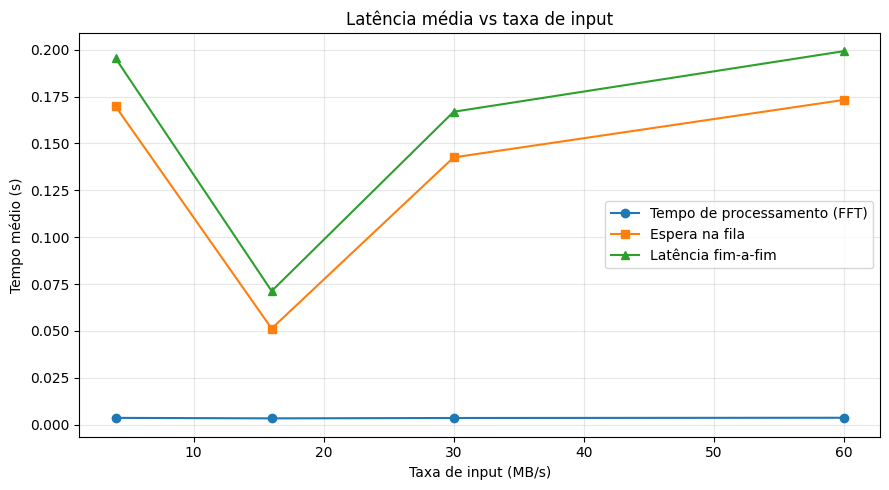

In [7]:
rate_values_mbps = [4, 16, 30, 60]

service_means = [processing_data[l]["service_time"]["mean_s"] for l in rate_labels]
queue_means   = [processing_data[l]["queue_wait"]["mean_s"] for l in rate_labels]
e2e_means     = [processing_data[l]["end_to_end_latency"]["mean_s"] for l in rate_labels]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rate_values_mbps, service_means, marker='o', label="Tempo de processamento (FFT)")
ax.plot(rate_values_mbps, queue_means, marker='s', label="Espera na fila")
ax.plot(rate_values_mbps, e2e_means, marker='^', label="Latência fim-a-fim")
ax.set_xlabel("Taxa de input (MB/s)")
ax.set_ylabel("Tempo médio (s)")
ax.set_title("Latência média vs taxa de input")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("latency_vs_rate.png", dpi=150)
plt.show()

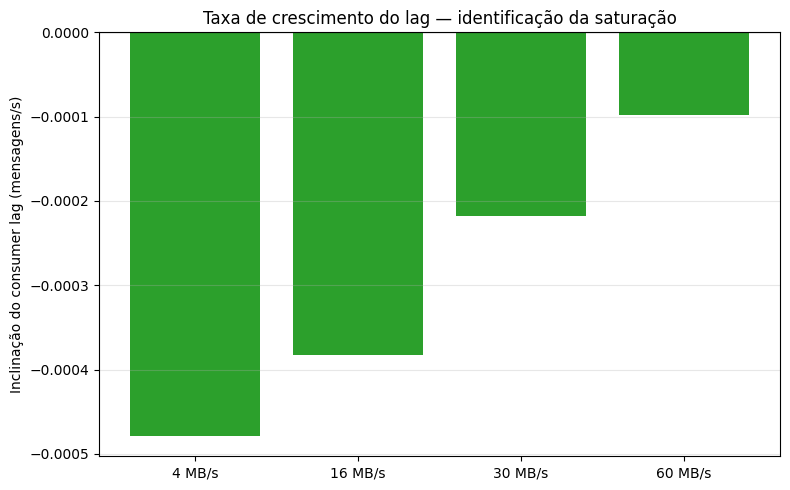

4 MB/s: inclinação = -0.0005 msg/s -> ESTÁVEL (λ < μ)
16 MB/s: inclinação = -0.0004 msg/s -> ESTÁVEL (λ < μ)
30 MB/s: inclinação = -0.0002 msg/s -> ESTÁVEL (λ < μ)
60 MB/s: inclinação = -0.0001 msg/s -> ESTÁVEL (λ < μ)


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
slopes = []
for label in rate_labels:
    df = snapshots_to_df(processing_data[label])
    slope, intercept = np.polyfit(df["elapsed_s"], df["consumer_lag"], 1)
    slopes.append(slope)

colors = ['tab:green' if s < 0.05 else 'tab:red' for s in slopes]
ax.bar(rate_labels, slopes, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Inclinação do consumer lag (mensagens/s)")
ax.set_title("Taxa de crescimento do lag — identificação da saturação")
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("saturation_slope.png", dpi=150)
plt.show()

for label, s in zip(rate_labels, slopes):
    status = "ESTÁVEL (λ < μ)" if s < 0.05 else "SATURADO (λ ≥ μ)"
    print(f"{label}: inclinação = {s:.4f} msg/s -> {status}")

In [9]:
summary_rows = []
for label, pm in processing_data.items():
    prod = producer_data[label]
    summary_rows.append({
        "Trial": label,
        "Partições (consumer)": pm.get("num_partitions_assigned"),
        "Chunks processados": pm.get("total_chunks_processed"),
        "Terminou naturalmente": pm.get("stream_ended_naturally"),
        "Duração (s)": round(pm.get("wall_clock_duration_s", 0), 1),
        "Taxa alvo (MB/s)": prod.get("target_rate_mb_s"),
        "Taxa alcançada (MB/s)": round(prod["achieved_avg_rate_mb_s"], 2) if prod.get("achieved_avg_rate_mb_s") else None,
        "Latência E2E média (s)": round(pm["end_to_end_latency"]["mean_s"], 4),
        "Tempo serviço médio (s)": round(pm["service_time"]["mean_s"], 4),
        "Espera fila média (s)": round(pm["queue_wait"]["mean_s"], 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Trial,Partições (consumer),Chunks processados,Terminou naturalmente,Duração (s),Taxa alvo (MB/s),Taxa alcançada (MB/s),Latência E2E média (s),Tempo serviço médio (s),Espera fila média (s)
0,1 partition (16MB/s),1,3968,True,227.1,16.0,12.67,0.0713,0.0034,0.0513
1,3 partitions (16MB/s),3,3968,True,210.8,16.0,12.72,0.0794,0.0042,0.0502
2,4 MB/s,3,3968,False,612.2,4.0,3.73,0.1953,0.0037,0.1697
3,16 MB/s,1,3968,True,227.1,16.0,12.67,0.0713,0.0034,0.0513
4,30 MB/s,1,3968,True,540.1,4.0,3.73,0.1669,0.0036,0.1426
5,60 MB/s,3,3968,False,548.4,4.0,3.74,0.1992,0.0037,0.1732
